In [ ]:
!python3 preprocess_smiles.py




In [15]:
!python3 prepare_dataset.py

[INFO] Total valid SMILES: 392895
[INFO] Vocab size: 51
[INFO] Train: 353605 | Val: 39290
[INFO] Saved train: (353605, 31), val: (39290, 30)


In [ ]:
# contains the splitting and cleaning 
# !python3 tokenizer.py 

In [18]:
import pickle
import numpy as np

data = pickle.load(open("data/tokenizer.pkl", "rb"))
# print("Sample shape:", data.shape)
# print("Sample tokens:", data[0])


In [19]:
!rm checkpoint_epoch_*.pt


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
from model import TransformerDecoder
from tqdm import tqdm

# Load cleaned and split data
train_data = pickle.load(open("data/train.pkl", "rb"))  # shape: (N, T)
val_data = pickle.load(open("data/val.pkl", "rb"))
vocab = open("data/vocab.txt").read().splitlines()
stoi = {s: i for i, s in enumerate(vocab)}
pad_id = stoi["<pad>"]

# Prepare train/val sets
train_x = torch.tensor(train_data[:, :-1], dtype=torch.long)
train_y = torch.tensor(train_data[:, 1:], dtype=torch.long)
val_x = torch.tensor(val_data[:, :-1], dtype=torch.long)
val_y = torch.tensor(val_data[:, 1:], dtype=torch.long)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(val_x, val_y), batch_size=128)

# Initialize model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training
epochs = 5
best_val_loss = float('inf')
print("Starting training...")

for epoch in range(epochs):
    total_train_loss = 0
    model.train()
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        output = model(batch_x)
        loss = criterion(output.view(-1, output.size(-1)), batch_y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    total_val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output.view(-1, output.size(-1)), batch_y.view(-1))
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)

    print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save checkpoint (overwrite or save best only)
    torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pt")


Starting training...


Epoch 1: 100%|██████████| 2763/2763 [20:47<00:00,  2.21it/s]


[Epoch 1] Train Loss: 1.3410 | Val Loss: 1.1725


Epoch 2:  61%|██████    | 1676/2763 [12:47<07:40,  2.36it/s]

In [ ]:
import torch
from model import TransformerDecoder

# Load vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}

# Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()


TransformerDecoder(
  (token_embed): Embedding(48, 256)
  (pos_encoder): PositionalEncoding()
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=

In [ ]:
# Code for Comparing Sampling methods

# --------------------- POST-TRAINING INFERENCE & EVALUATION -----------------------

import torch
from model import TransformerDecoder
from rdkit import Chem
from rdkit.Chem import Draw
import random

# Load model and vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()

# ---------- Top-k and Top-p Utilities ----------
def top_k_logits(logits, k):
    topk = torch.topk(logits, k)
    mask = logits < topk.values[..., -1, None]
    logits = logits.masked_fill(mask, float('-inf'))
    return logits

def top_p_logits(logits, p):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    mask = cumulative_probs > p
    mask[..., 1:] = mask[..., :-1].clone()
    mask[..., 0] = False
    sorted_logits[mask] = float('-inf')
    return torch.zeros_like(logits).scatter(-1, sorted_indices, sorted_logits)

# ---------- Unified Sampling Function ----------
def sample_smiles(method="multinomial", max_len=64, temperature=1.0, k=20, p=0.9):
    generated = [stoi["<bos>"]]
    for _ in range(max_len):
        input_ids = torch.tensor(generated).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :] / temperature

            if method == "top_k":
                logits = top_k_logits(logits, k)
            elif method == "top_p":
                logits = top_p_logits(logits, p)
            # else: use raw logits (multinomial)

            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == stoi["<eos>"]:
            break
        generated.append(next_id)

    tokens = [itos[i] for i in generated[1:]]  # skip <bos>
    return "".join(tokens)

# ---------- Evaluation Function ----------
def evaluate_model(method="multinomial", num_samples=1000, **kwargs):
    smiles_list = [sample_smiles(method=method, **kwargs) for _ in range(num_samples)]
    valid = [s for s in smiles_list if Chem.MolFromSmiles(s)]
    unique = list(set(valid))

    print(f"🔹 {method.upper()} SAMPLING")
    print(f"Generated: {len(smiles_list)}")
    print(f"✅ Valid: {len(valid)} ({len(valid)/len(smiles_list)*100:.2f}%)")
    print(f"🧬 Unique: {len(unique)} ({len(unique)/len(valid)*100:.2f}%)")
    print("-" * 50)

    return valid, unique

# ---------- Visualization ----------
def visualize_molecules(smiles_list, n=9):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list[:n]]
    return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))

# ---------- Run All Methods ----------
if __name__ == "__main__":
    methods = [
        ("multinomial", {"temperature": 1.0}),
        ("top_k", {"temperature": 1.0, "k": 20}),
        ("top_p", {"temperature": 1.0, "p": 0.9}),
    ]

    for method_name, params in methods:
        valid, unique = evaluate_model(method=method_name, num_samples=1000, **params)
        visualize_molecules(unique, n=9)


In [ ]:
import matplotlib.pyplot as plt

# After evaluate_model() runs for each method
results = {
    "Multinomial": {"valid": 897, "unique": 897},
    "Top-k": {"valid": 906, "unique": 906},
    "Top-p": {"valid": 966, "unique": 965},
}

total = 1000
methods = list(results.keys())
valid_perc = [results[m]["valid"] / total * 100 for m in methods]
unique_perc = [results[m]["unique"] / results[m]["valid"] * 100 for m in methods]

x = range(len(methods))

plt.figure(figsize=(10, 5))
plt.bar(x, valid_perc, width=0.4, label="Validity %", align='center')
plt.bar([i + 0.4 for i in x], unique_perc, width=0.4, label="Uniqueness %", align='center')
plt.xticks([i + 0.2 for i in x], methods)
plt.ylabel("Percentage")
plt.title("Sampling Method Comparison (1000 Samples)")
plt.legend()
plt.grid(axis='y')
plt.show()


In [ ]:
# End comparing sampling methods
# --------------------- END OF POST-TRAINING INFERENCE & EVALUATION -----------------------

Generated: 1000
✅ Valid: 899 (89.90%)
🧬 Unique: 899 (100.00%)


[10:08:47] Can't kekulize mol.  Unkekulized atoms: 2 5 6
[10:08:47] Can't kekulize mol.  Unkekulized atoms: 1 3 4
[10:08:47] Explicit valence for atom # 2 O, 3, is greater than permitted
[10:08:47] SMILES Parse Error: ring closure 1 duplicates bond between atom 1 and atom 2 for input: 'C[C@]1([C@@H]1CC)C[C@@H](C)O'
[10:08:47] SMILES Parse Error: unclosed ring for input: '[C@@H]12C34C1(C23O5)C[N@H+]1C5#N'
[10:08:47] SMILES Parse Error: unclosed ring for input: 'O1[C@]2(C[C@@]2([C@H]2C1)O)C'
[10:08:47] SMILES Parse Error: ring closure 2 duplicates bond between atom 2 and atom 7 for input: 'N#C[C@@]12[C@]3(O)[C@@H](C3)[C@@]12C'
[10:08:47] SMILES Parse Error: unclosed ring for input: 'C1[C@H]2C[C@H]2[C@]1(CC2)C#C'
[10:08:47] Can't kekulize mol.  Unkekulized atoms: 0 2 5
[10:08:47] Can't kekulize mol.  Unkekulized atoms: 0 1 2 5 6
[10:08:47] SMILES Parse Error: ring closure 2 duplicates bond between atom 0 and atom 6 for input: '[C@@H]12C(C)([C@H]3[C@H](C3)[C@H]21)CO'
[10:08:47] Can't kekul

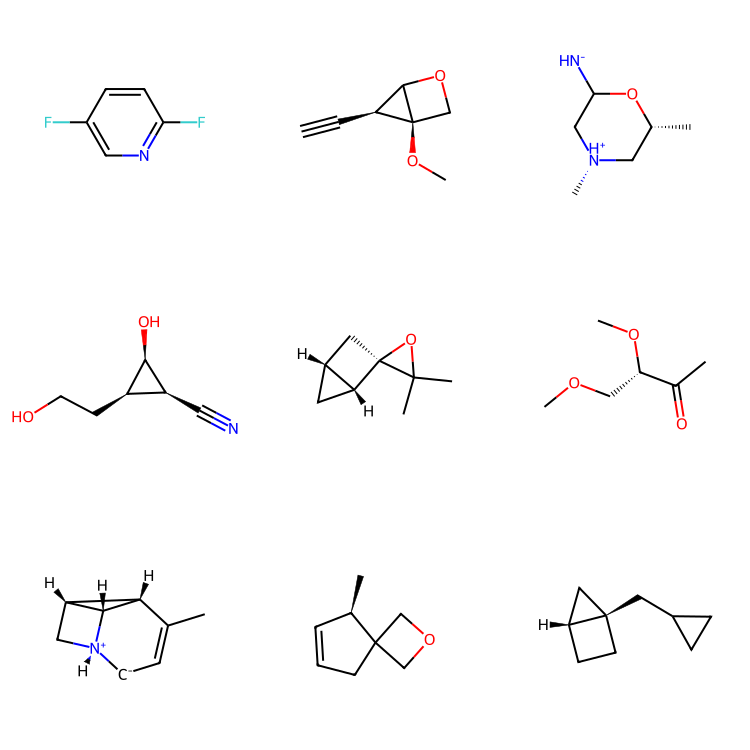

In [1]:
# --------------------- POST-TRAINING INFERENCE & EVALUATION -----------------------

import torch
from model import TransformerDecoder
from rdkit import Chem
from rdkit.Chem import Draw
import random

# Load model and vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()

# Sampling
def sample_smiles(max_len=64, temperature=1.0):
    generated = [stoi["<bos>"]]
    for _ in range(max_len):
        input_ids = torch.tensor(generated).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
        if next_id == stoi["<eos>"]:
            break
        generated.append(next_id)
    tokens = [itos[i] for i in generated[1:]]  # Skip <bos>
    return "".join(tokens)

# Evaluation
def evaluate_model(num_samples=1000):
    smiles_list = [sample_smiles() for _ in range(num_samples)]
    valid = [s for s in smiles_list if Chem.MolFromSmiles(s)]
    unique = list(set(valid))

    print(f"Generated: {len(smiles_list)}")
    print(f"✅ Valid: {len(valid)} ({len(valid)/len(smiles_list)*100:.2f}%)")
    print(f"🧬 Unique: {len(unique)} ({len(unique)/len(valid)*100:.2f}%)")
    return valid, unique

# Visualization
def visualize_molecules(smiles_list, n=9):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list[:n]]
    return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))

# ------------------ Run Everything -------------------
valid, unique = evaluate_model(num_samples=1000)
visualize_molecules(unique, n=9)


In [2]:
import torch
from model import TransformerDecoder
import random

# Load vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}

pad_id = stoi["<pad>"]
bos_id = stoi["<bos>"]
eos_id = stoi["<eos>"]

# Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt"))
model.eval()

def sample_smiles(max_len=64, temperature=1.0):
    generated = [bos_id]
    for _ in range(max_len):
        input_ids = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)  # (1, T)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :]  # last token
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == eos_id:
            break
        generated.append(next_id)

    tokens = [itos[i] for i in generated[1:]]  # skip <bos>
    return "".join(tokens)

# Generate 10 samples
samples = [sample_smiles() for _ in range(10)]
for i, smi in enumerate(samples):
    print(f"[{i+1}] {smi}")


[1] N[C@](C)(C(=O)N)[C@H](N)C
[2] C(CC)[C@H]1[C@H]2C[C@@H]3[C@H]2C3
[3] [C@H]12[C@@](C2)(C(O1)C=O)OC
[4] CC[C@]1([C@@H](C)C1(C)C)C
[5] C1[C@@H]2C[C@@H](OC2)[C@H](C)O1
[6] OCC[C@@](COC)(C)O
[7] [C@@H]12CC[C@]2(O)[C@@]2(O)[C@H]1C2
[8] N(\[H])=C(/Nc1ccc[nH]1)C
[9] C1[C@@H]2[C@@]34C[N@@H+]2C[C@H]4[C@@H]1O3
[10] c1cc(OC)cc(c1)N


In [3]:
from rdkit import Chem

valid_count = 0
for smi in samples:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        valid_count += 1
print(f"Valid molecules: {valid_count}/{len(samples)}")


Valid molecules: 9/10


[11:13:00] SMILES Parse Error: unclosed ring for input: 'C(CC)[C@H]1[C@H]2C[C@@H]3[C@H]2C3'


[11:55:17] Can't kekulize mol.  Unkekulized atoms: 0 4 5
[11:55:17] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8
[11:55:17] Can't kekulize mol.  Unkekulized atoms: 2 4 5
[11:55:18] Explicit valence for atom # 8 C, 5, is greater than permitted
[11:55:18] Can't kekulize mol.  Unkekulized atoms: 5 6 7 9
[11:55:19] SMILES Parse Error: unclosed ring for input: '[C@@H]12N[C@H]2[C@H]([C@H]2O)[NH2+][CH+]1'
[11:55:19] SMILES Parse Error: ring closure 3 duplicates bond between atom 3 and atom 4 for input: 'C[C@]12[C@](C34C31O4)(C=O)C2'
[11:55:19] SMILES Parse Error: ring closure 2 duplicates bond between atom 2 and atom 8 for input: 'O=C[C@]12[C@@H](C)[C@H](CO)[C@@H]21'
[11:55:20] SMILES Parse Error: unclosed ring for input: '[C@@]12(C[N@H+]3[C@@H]2[C@@H]21)[C@@H]1[C@@H](C2)O1'
[11:55:21] Can't kekulize mol.  Unkekulized atoms: 2 3 4 7
[11:55:22] SMILES Parse Error: unclosed ring for input: 'C1C[NH+]1[C@@H](C)[C@@]1(CO)C'
[11:55:22] SMILES Parse Error: ring closure 2 duplicates bond between

[11:55:52] Can't kekulize mol.  Unkekulized atoms: 0 3 6 7
[11:55:52] SMILES Parse Error: ring closure 1 duplicates bond between atom 0 and atom 8 for input: 'c1(c(N)c2[nH][nH+]cc2)o1'
[11:55:54] Explicit valence for atom # 6 N, 4, is greater than permitted


Generated: 1000
Valid: 915 (91.50%)
Unique: 915 (100.00%)


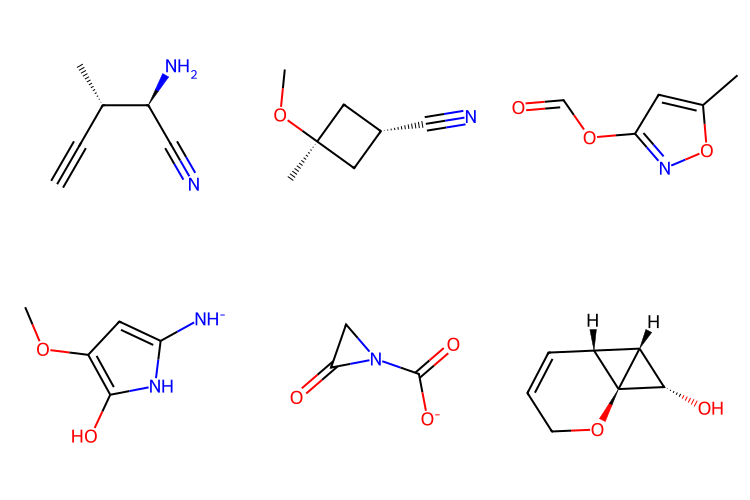

In [11]:
import torch
import random
from rdkit import Chem
from rdkit.Chem import Draw
from model import TransformerDecoder

# ---------- Load Model + Vocabulary ----------
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}
pad_id, bos_id, eos_id = stoi["<pad>"], stoi["<bos>"], stoi["<eos>"]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt"))
model.eval()


# ---------- Sampling Function ----------
def sample_smiles(max_len=64, temperature=1.0):
    generated = [bos_id]
    for _ in range(max_len):
        input_ids = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
        if next_id == eos_id:
            break
        generated.append(next_id)
    tokens = [itos[i] for i in generated[1:]]  # skip <bos>
    return "".join(tokens)


# ---------- Evaluation Function ----------
def evaluate_model(num_samples=1000):
    valid_smiles = []
    for _ in range(num_samples):
        smi = sample_smiles()
        mol = Chem.MolFromSmiles(smi)
        if mol:
            valid_smiles.append(smi)
    
    validity = len(valid_smiles) / num_samples
    uniqueness = len(set(valid_smiles)) / len(valid_smiles) if valid_smiles else 0

    print(f"Generated: {num_samples}")
    print(f"Valid: {len(valid_smiles)} ({validity*100:.2f}%)")
    print(f"Unique: {len(set(valid_smiles))} ({uniqueness*100:.2f}%)")

    return valid_smiles


# ---------- Visualization Function ----------
def visualize_samples(valid_smiles, n=6):
    """Render up to n valid molecules in a grid."""
    sample_n = min(n, len(valid_smiles))
    sampled_mols = [Chem.MolFromSmiles(s) for s in random.sample(valid_smiles, sample_n)]
    return Draw.MolsToGridImage(sampled_mols, molsPerRow=3, subImgSize=(250, 250))


# ---------- Run Post-Training Analysis ----------
# Step 1: Evaluate
valid_smiles = evaluate_model(num_samples=1000)

# Step 2: Visualize (if there are valid molecules)
if valid_smiles:
    img = visualize_samples(valid_smiles, n=6)
    display(img)  # If in notebook
